In [ ]:
import numpy as np
import cv2 as cv2
import os
import math
from math import copysign, log10
import matplotlib.pyplot as plt

In [32]:
img = cv2.imread('Snowflake.jpeg', 0)
# Convert to binary using a threshold value of 127
_, binary_img = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

#invert = cv2.bitwise_not(binary_img)

In [33]:
cv2.imshow("Binary Image", binary_img)
cv2.waitKey(0)
cv2.destroyAllWindows()
cv2.imwrite('Binary_Snowflake_Real.jpg', binary_img)

True

In [ ]:
# Load the image
image = cv2.imread('Binary_Snowflake_Real.jpg', 0)

# Apply thresholding
ret, thresh = cv2.threshold(image, 127, 255, 0)
# Find contours (Only 1 shape per image as a result)
contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
# Calculate moments for the contour
c = max(contours, key=cv2.contourArea)
M = cv2.moments(c)

# Print moments
print(M)

{'m00': 5365.0, 'm10': 554123.0, 'm01': 632637.8333333333, 'm20': 68026368.16666666, 'm11': 67504616.08333333, 'm02': 83035240.33333333, 'm30': 9375105771.5, 'm21': 8488928279.583333, 'm12': 9057413168.916666, 'm03': 11787946305.25, 'mu20': 10793879.978595823, 'mu11': 2162738.334933214, 'mu02': 8434936.854359552, 'mu30': 119327669.28625679, 'mu21': 20540530.239060163, 'mu12': -28923581.835586905, 'mu03': 7190501.618385315, 'nu20': 0.3750059271883475, 'nu11': 0.07513884684336845, 'nu02': 0.29305044359551624, 'nu30': 0.05660005357757207, 'nu21': 0.009742879576853035, 'nu12': -0.013719167493519917, 'nu03': 0.003410632079588439}


In [35]:
cx = int(M['m10'] / M['m00'])
cy = int(M['m01'] / M['m00'])
print(f"Centroid: ({cx}, {cy})")

Centroid: (103, 117)


In [ ]:
image = cv2.imread('Binary_Snowflake_Real.jpg')
# Define the centre coordinates, radius, colour, and thickness
centre_coordinates = (cx, cy)
radius = 1
colour = (255, 0, 0) # Blue colour
thickness = 5
# Draw the circle
image = cv2.circle(image, centre_coordinates, radius, colour, thickness)

cv2.imshow('Image with Circle', image)
cv2.waitKey(0)
cv2.destroyAllWindows()
cv2.imwrite('Centroid_Snowflake_Real.jpg',image)

True

In [ ]:
#Recentre image

def recentre_image(image, centroid):
    h, w = image.shape[:2]
    cx, cy = centroid
    
    # Calculate translation needed to move centroid to centre
    dx = w//2 - cx
    dy = h//2 - cy
    
    
    M = np.array([[1, 0, dx], [0, 1, dy]], dtype = np.float32)
    recentred = cv2.warpAffine(image, M, (w, h))
    
    return recentred, (w//2, h//2)  

In [ ]:
#Padding Image so rotation does not clip

def pad_to_square(image, new_centroid):
    h, w = image.shape[:2]
    cx, cy = new_centroid
    
    # Find maximum distance to any edge
    max_dist = max(cx, w-cx, cy, h-cy)
    
    # Calculate padding needed
    new_size = 8 * max_dist
    pad_x = (new_size - w) // 2
    pad_y = (new_size - h) // 2
    
    # Apply symmetric padding
    padded = cv2.copyMakeBorder(
        image, pad_y, pad_y, pad_x, pad_x, 
        cv2.BORDER_CONSTANT, value=0
    )
    
    # New centroid is at centre of padded image
    new_cx = pad_x + cx
    new_cy = pad_y + cy
    
    return padded, (new_cx, new_cy)

In [ ]:
fresh_image = cv2.imread('Binary_Snowflake_Real.jpg', cv2.IMREAD_COLOR)

recentred, new_centroid = recentre_image(fresh_image, (cx, cy))

padded, final_centroid = pad_to_square(recentred, new_centroid)

cv2.imshow('Recentred and Padded', padded)
cv2.waitKey(0)
cv2.destroyAllWindows()

cv2.imwrite('Centered_Snowflake_Real.jpg', padded)



True

In [ ]:
image_path = 'Centered_Snowflake_Real.jpg'
image = cv2.imread(image_path)
h, w = image.shape[:2]

# Calculate the centre of the already centred image
centre_x = w // 2
centre_y = h // 2

angles_list = []
scores_list = []
detected_symmetry_angles = []

i = 0
while i <= 180:
    # Load fresh copy for each iteration
    image = cv2.imread(image_path)
    h, w = image.shape[:2]
    
    # Rotation angle
    theta_deg = i
    theta = math.radians(theta_deg)
    
    # Create a long line through centroid
    length = max(h, w) * 2
    
    # Calculate direction vector
    dx = math.sin(theta)
    dy = math.cos(theta)
    
    # Calculate endpoints of the rotated line
    x1 = int(centre_x - length * dx)
    y1 = int(centre_y - length * dy)
    x2 = int(centre_x + length * dx)
    y2 = int(centre_y + length * dy)
    
    # Draw rotated line
    cv2.line(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
    
    # Rotate the entire image so the line appears vertical
    rotation_matrix = cv2.getRotationMatrix2D((centre_x, centre_y), -i, 1.0)
    rotated_image = cv2.warpAffine(image, rotation_matrix, (w, h))

    # Convert rotated image to binary for moment calculation
    gray = cv2.cvtColor(rotated_image, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    
    # Use centre_x as the split point
    cx = centre_x
    
    # Compare left and right halves
    left_half = thresh[:, :cx]  
    right_half = thresh[:, cx:]  
    right_half_flipped = cv2.flip(right_half, 1)  

    M_left = cv2.moments(left_half)
    M_right = cv2.moments(right_half)
    
    # Calculate symmetry score (lower = more symmetric) 
    if M_left["m00"] + M_right['m00'] > 0:
        symm_score = (abs(M_right["m00"] - M_left['m00']) / (M_right["m00"] + M_left['m00']))
        
        angles_list.append(i)
        scores_list.append(symm_score)
        
        symm_thresh = 0.02

        if symm_score <= symm_thresh:
            print(f'{i}° is a line of symmetry (score: {symm_score:.4f})')
            detected_symmetry_angles.append(i)

    else:
        symm_score = 0.0  

    angles_list.append(i)
    scores_list.append(symm_score)
    
    i += 1  # Increment by 1

    # Reload original image cleanly
base = cv2.imread(image_path)
h, w = base.shape[:2]
cx, cy = w // 2, h // 2

# For each symmetry angle we  draw the infinite line across the image
for angle in detected_symmetry_angles:
    
    theta = math.radians(angle)
    dx = math.sin(theta)
    dy = math.cos(theta)
    
    L = max(h, w) * 2  # Large so line crosses whole image
    
    x1 = int(cx - L * dx)
    y1 = int(cy - L * dy)
    x2 = int(cx + L * dx)
    y2 = int(cy + L * dy)
    
    # Draw line onto the image
    cv2.line(base, (x1, y1), (x2, y2), (0, 0, 255), 2)

# Save output
cv2.imwrite("symmetry_lines_Snowflake_Raw.png", base)

158° is a line of symmetry (score: 0.0182)
162° is a line of symmetry (score: 0.0191)
163° is a line of symmetry (score: 0.0185)
164° is a line of symmetry (score: 0.0124)
165° is a line of symmetry (score: 0.0119)
178° is a line of symmetry (score: 0.0199)
179° is a line of symmetry (score: 0.0182)
180° is a line of symmetry (score: 0.0083)

Saved: symmetry_lines_overlay.png


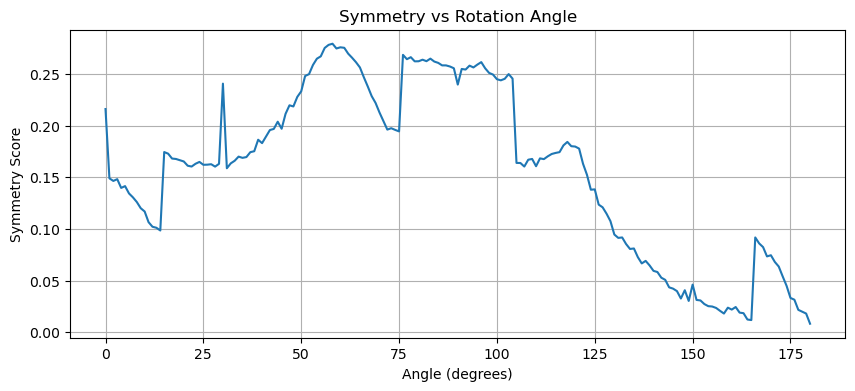

In [48]:
#Plot a graph of angle against symmetry score

plt.figure(figsize=(10, 4))
plt.plot(angles_list, scores_list)
plt.xlabel('Angle (degrees)')
plt.ylabel('Symmetry Score')
plt.title('Symmetry vs Rotation Angle')
plt.grid(True)
plt.show()

In [ ]:
image_path = 'Centered_Snowflake_Real.jpg' 
image = cv2.imread(image_path)
h, w = image.shape[:2]

centre_x = w // 2
centre_y = h // 2

angles_list = []
scores_list = []
detected_symmetry_angles = []

i = 0
while i <= 180:
  
    image = cv2.imread(image_path)
    h, w = image.shape[:2]
    
    theta_deg = i
    theta = math.radians(theta_deg)
    
    length = max(h, w) * 2
    
    dx = math.sin(theta)
    dy = math.cos(theta)
    
    x1 = int(centre_x - length * dx)
    y1 = int(centre_y - length * dy)
    x2 = int(centre_x + length * dx)
    y2 = int(centre_y + length * dy)
    
    rotation_matrix = cv2.getRotationMatrix2D((centre_x, centre_y), -i, 1.0)
    rotated_image = cv2.warpAffine(
        image, rotation_matrix, (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT, #For edge pixel artefacts
        borderValue= 0
    )

    gray = cv2.cvtColor(rotated_image, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    

    cx = centre_x
  
    left_half = thresh[:, :cx]   
    right_half = thresh[:, cx:]  
    right_half_flipped = cv2.flip(right_half, 1)  

    # Calculate moments for both halves
    M_left = cv2.moments(left_half)
    M_right = cv2.moments(right_half_flipped)

    # Calculate Hu Moments for left and right halves
    hu_left = cv2.HuMoments(M_left)
    hu_right = cv2.HuMoments(M_right)


    # Calculate symmetry score using hu moments
    if hu_left is not None and hu_right is not None:
        
        h1_left = hu_left[0][0]     #Next step is to look at then individually and plot against angle
        h1_right = hu_right[0][0]
        h2_left = hu_left[1][0]
        h2_right = hu_right[1][0]
        h3_left = hu_left[2][0]  
        h3_right = hu_right[2][0]  
        h4_left = hu_left[3][0]
        h4_right = hu_right[3][0]
        h5_left = hu_left[4][0]
        h5_right = hu_right[4][0]
        h6_left = hu_left[5][0]
        h6_right = hu_right[5][0]
        h7_left = hu_left[6][0]
        h7_right = hu_right[6][0]
        
        eps = 1e-15  # prevents log(0)
        
        #Normalise the Hu Moments
        h1_left_normalised = -copysign(1.0, h1_left) * log10(abs(h1_left) + eps) 
        h1_right_normalised = -copysign(1.0, h1_right) * log10(abs(h1_right) + eps)
        h2_left_normalised = -copysign(1.0, h2_left) * log10(abs(h2_left) + eps)
        h2_right_normalised = -copysign(1.0, h2_right) * log10(abs(h2_right) + eps)
        h3_left_normalised = -copysign(1.0, h3_left) * log10(abs(h3_left) + eps)
        h3_right_normalised = -copysign(1.0, h3_right) * log10(abs(h3_right) + eps)
        h4_left_normalised = -copysign(1.0, h4_left) * log10(abs(h4_left) + eps)
        h4_right_normalised = -copysign(1.0, h4_right) * log10(abs(h4_right) + eps)
        h5_left_normalised = -copysign(1.0, h5_left) * log10(abs(h5_left) + eps)
        h5_right_normalised = -copysign(1.0, h5_right) * log10(abs(h5_right) + eps)
        h6_left_normalised = -copysign(1.0, h6_left) * log10(abs(h6_left) + eps)
        h6_right_normalised = -copysign(1.0, h6_right) * log10(abs(h6_right) + eps)
        h7_left_normalised = -copysign(1.0, h7_left) * log10(abs(h7_left) + eps)
        h7_right_normalised = -copysign(1.0, h7_right) * log10(abs(h7_right) + eps)
        
        # Calculate absolute difference between normalised values
        h1_difference = abs(h1_left_normalised - h1_right_normalised)
        h2_difference = abs(h2_left_normalised - h2_right_normalised)
        h3_difference = abs(h3_left_normalised - h3_right_normalised)
        h4_difference = abs(h4_left_normalised - h4_right_normalised)
        h5_difference = abs(h5_left_normalised - h5_right_normalised) 

        arr_difference = np.array([h1_difference, h2_difference, h3_difference, h4_difference, h5_difference])
        
        #Average difference
        arr = np.array([h1_difference, h2_difference, h3_difference, h4_difference, h5_difference])
        avg_difference = np.mean(arr)
        # Convert difference to similarity score (lower = more symmetric)
        symm_score = avg_difference
        
        symm_thresh = 0.15

        if symm_score <= symm_thresh:
            print(f'{i}° is a line of symmetry (score: {symm_score:.4f})')
            detected_symmetry_angles.append(i)

    else:
        symm_score = 0.0  

    angles_list.append(i)
    scores_list.append(symm_score)

    i += 1  


# Reload original image cleanly
base = cv2.imread(image_path)
h, w = base.shape[:2]
cx, cy = w // 2, h // 2

# For each symmetry angle we draw the infinite line across the image
for angle in detected_symmetry_angles:
    
    theta = math.radians(angle)
    dx = math.sin(theta)
    dy = math.cos(theta)
    
    L = max(h, w) * 2  # Large so line crosses whole image
    
    x1 = int(cx - L * dx)
    y1 = int(cy - L * dy)
    x2 = int(cx + L * dx)
    y2 = int(cy + L * dy)
    
    # Draw line onto the image
    cv2.line(base, (x1, y1), (x2, y2), (0, 0, 255), 2)

# Save output
cv2.imwrite("symmetry_lines_Snowflake.png", base)


4° is a line of symmetry (score: 0.1212)
5° is a line of symmetry (score: 0.1203)
43° is a line of symmetry (score: 0.1437)
109° is a line of symmetry (score: 0.1474)
110° is a line of symmetry (score: 0.1460)
111° is a line of symmetry (score: 0.1465)
112° is a line of symmetry (score: 0.1302)
113° is a line of symmetry (score: 0.1129)
114° is a line of symmetry (score: 0.1150)
115° is a line of symmetry (score: 0.1016)
116° is a line of symmetry (score: 0.0696)
117° is a line of symmetry (score: 0.0625)
118° is a line of symmetry (score: 0.0500)
127° is a line of symmetry (score: 0.0897)
128° is a line of symmetry (score: 0.1210)
129° is a line of symmetry (score: 0.1352)
135° is a line of symmetry (score: 0.1114)
136° is a line of symmetry (score: 0.1265)
137° is a line of symmetry (score: 0.1009)
138° is a line of symmetry (score: 0.0947)
139° is a line of symmetry (score: 0.0720)
140° is a line of symmetry (score: 0.0758)
141° is a line of symmetry (score: 0.0941)
142° is a line o

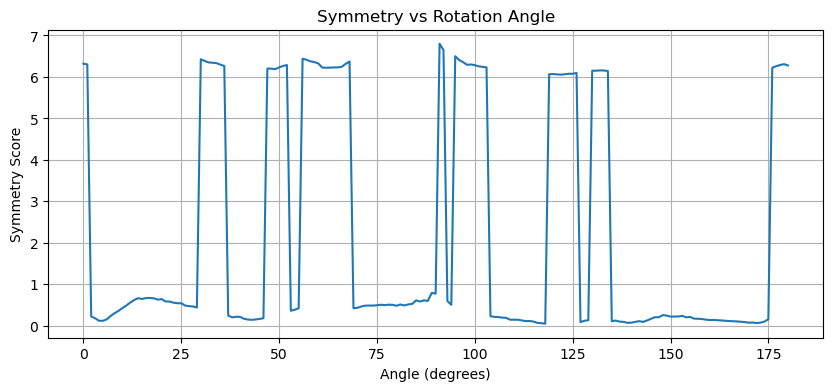

In [51]:
#Plot a graph of angle against symmetry score

plt.figure(figsize=(10, 4))
plt.plot(angles_list, scores_list)
plt.xlabel('Angle (degrees)')
plt.ylabel('Symmetry Score')
plt.title('Symmetry vs Rotation Angle')
plt.grid(True)
plt.show()